In [1]:
##IMPORTING LIBRARIES
import time
import random
import numpy as np
import pandas as pd
import seaborn as sns
from numpy.linalg import inv
import matplotlib.pyplot as plt

| Variable   | Parameter                                 | Value  | Unit         |
|------------|------------------------------------------|--------|--------------|
| $m_{c}$    | The mass of the cart                     | 0.360  | $kg$         |
| $m_{p}$    | The mass of the pendulum rod             | 0.179  | $kg$         |
| $\ell$     | The length of the pendulum rod           | 0.463  | $m$          |
| $g$        | The acceleration due to gravity          | 9.810  | $m/s^2$      |

In [2]:
## DEFINING SYSTEM CONSTANTS
m_c = 0.360  # Cart mass (kg)
m_p = 0.179  # Pendulum mass (kg)
ell = 0.463  # Pendulum length (m)
g = 9.810    # Acceleration due to gravity (m/s^2)
k = (2*np.pi)/1024

## Damping Factor $\lambda$
The damping factor $\lambda$ quantifies the decay in oscillatory amplitude over successive cycles due to energy dissipation, typically from sources such as air resistance or mechanical friction.
It reflects how rapidly the system's motion loses energy after being disturbed.

#### Mathematical Definition
Let $\theta_n$ be the amplitude of the pendulum oscillation in the $n$-th cycle, and $\theta_{n+1}$ be the amplitude in the subsequent cycle. 
The damping factor is defined as,
\begin{equation*}
\lambda = \frac{\theta_{n+1}}{\theta_{n}}
\end{equation*}
Where:
* $\lambda$ is dimensionless and satisfies $0 < \lambda \leq 1$.
* Lower values of $\lambda$ indicate stronger damping.
* $\lambda = 1$ represents an undamped system.
* For example, $\lambda = 0.5$ implies the amplitude is halved every cycle.

## Relationship with the Damping Rate $\gamma$
The damping factor is related to the damping rate $\gamma$ by,
\begin{equation*}
\gamma = -\frac{\ln(\lambda)}{T} 
\end{equation*}
Where $T$ is the period of the damped oscillation (the time for one complete cycle).

## Moment of Inertia $I_{m}$
The rotary inertia $I_{m}$ of the pendulum depends on its mass distribution relative to the pivot. Assuming the pendulum consists of a homogeneous rod or includes a point mass at the tip, the following models are used, homogeneous Slender Rod Pivoted at One End,
\begin{equation*}
I_{m} = \frac{1}{3} m_p \ell^2 
\end{equation*}

If $\gamma$ and $T$ are known, the rotational viscous friction coefficient $\mu_{p}$ can be estimated as
\begin{equation*}
\mu_p = 2 I_{m} \gamma
\end{equation*}
Where $I_{m}$ is the rotary inertia of the pendulum rod.

## Viscous Friction Model
Viscous friction is modeled as a force proportional to velocity. For the cart, the viscous friction coefficient $\mu_{c}$ can be approximated using the relation:
\begin{equation*}
\mu_c = \frac{m_c a}{v}
\end{equation*}
Where:
* $m_{c}$: Mass of the cart $(kg)$,
* $a$: Acceleration of the cart $(m/s^2)$,
* $v$: Velocity of the cart $(m/s)$.
  
This provides an empirical method for estimating the linear viscous friction affecting the cart's motion.

How to Calculate $a$ from Data?
If we have a dataset with time and velocity, we can calculate acceleration as:

$$ a =\frac{\Delta v}{\Delta t}$$
  
I.e:

$$ a =\frac{v_f - v_i}{t_f - t_i}$$

Then we can calculate $\mu_c$ for each point and get an average.

## 15/Feb/25 
### 14:42

In [3]:
df = pd.read_csv('CSV/Data_15_Feb_25_14-42.csv',header=None)
df = df.T
df.columns = ["x1","x3","Error","RealTime","simulateTime"]
df

,x1,x3,Error,RealTime,simulateTime
0,0.0,1.0,0.005677,0.055677,0.05
1,1.0,1.0,-0.001591,0.098409,0.10
2,2.0,1.0,-0.005413,0.144587,0.15
3,3.0,1.0,0.001436,0.201436,0.20
4,4.0,1.0,0.004735,0.254735,0.25
...,...,...,...,...,...
1195,1195.0,512.0,0.006016,59.806016,59.80
1196,1196.0,512.0,-0.005163,59.844837,59.85
1197,1197.0,512.0,-0.005992,59.894008,59.90
1198,1198.0,512.0,0.005139,59.955139,59.95


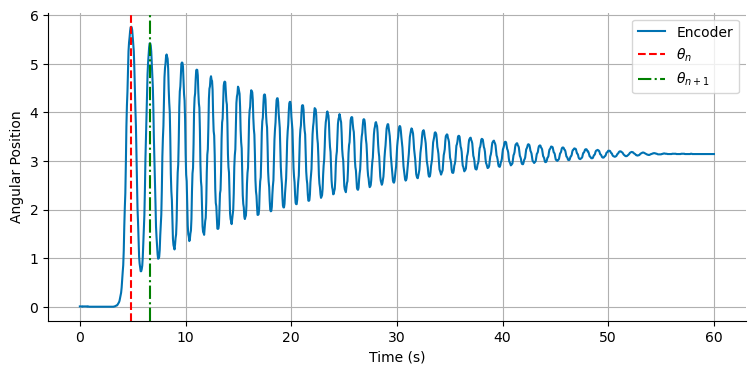

In [38]:
plt.figure(figsize=(9, 4))
t = np.linspace(0, 60, len(df))
plt.plot(t, df['x3'] * k, color='#0072B2', label='Encoder')
#plt.title("Adjustments to Acquired Data")
plt.ylabel("Angular Position")
plt.xlabel("Time (s)")
plt.axvline(x=t[97], color='r', linestyle='--', label=r'$\theta_{n}$')   
plt.axvline(x=t[133], color='g', linestyle='-.', label=r'$\theta_{n+1}$')  
plt.grid(True)
plt.legend()
sns.despine()
plt.savefig('figure_sipe_1.pdf', format="pdf",bbox_inches='tight')
plt.show()

In [75]:
(df['x3'][97])*k

5.7616318392984684

$\theta_{n} = 5.7616318392984684$

In [76]:
(df['x3'][133])*k

5.418020142812084

$\theta_{n+1} = 5.418020142812084$

In [77]:
lamb = ((df['x3'][133])*k) / ((df['x3'][97])*k)
lamb

0.9403620873269435

$$\lambda = 0.9403620873269436$$

$T = 36$

$$\lambda = \frac{\theta_{n+1}}{\theta_{n}}$$

$\theta_{n} = 937$

$\theta_{n+1} = 883$

$T = 36$

$$\lambda = 0.9403620873269436$$

In [4]:
lamb = 0.9403620873269436
T = 36 * .05
T

1.8

$$\gamma = -\frac{\ln(\lambda)}{T} $$

In [5]:
gamma = -np.log(lamb)/T
gamma

0.03416126589127936

$$I = \frac{1}{3} m_h L^2$$

$m_h=0.179$ $kg$

$L=0.463$ $m$

In [194]:
m_h = 0.179
L = 0.463
I = 1/3 * m_h * L**2
round(I,3)

0.013

$$b = 2I \gamma$$

In [197]:
b = 2*I*gamma
round(b,3)

0.001

## 15/Feb/25 
### 14:45

In [45]:
df = pd.read_csv('CSV/Data_15_Feb_25_14-45.csv',header=None)
df = df.T
df.columns = ["x1","x3","Error","RealTime","simulateTime"]
df

,x1,x3,Error,RealTime,simulateTime
0,0.0,38.0,0.006244,0.056244,0.05
1,1.0,52.0,-0.001770,0.098230,0.10
2,2.0,66.0,-0.007175,0.142825,0.15
3,3.0,85.0,0.001914,0.201914,0.20
4,4.0,118.0,0.007588,0.257588,0.25
...,...,...,...,...,...
1196,1196.0,512.0,-0.006969,59.843031,59.85
1197,1197.0,512.0,0.038730,59.938730,59.90
1198,1198.0,512.0,0.007982,59.957982,59.95
1199,1199.0,512.0,-0.037301,59.962699,60.00


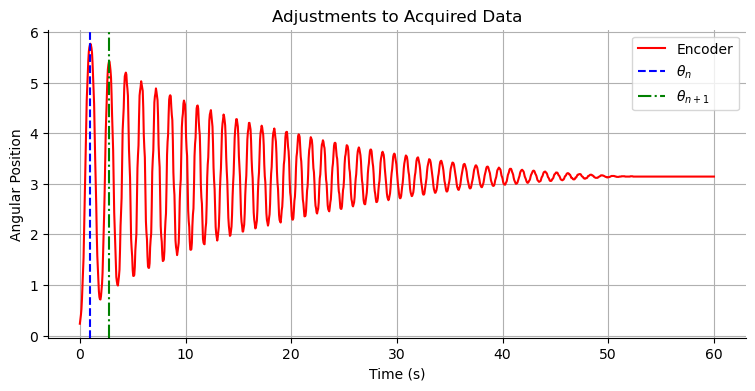

In [48]:
plt.show()
plt.figure(figsize=(9, 4))
t = np.linspace(0, 60, len(df))
plt.plot(t, df['x3'] * k, color='r', label='Encoder')
plt.title("Adjustments to Acquired Data")
plt.ylabel("Angular Position")
plt.xlabel("Time (s)")
plt.axvline(x=t[20], color='b', linestyle='--', label=r'$\theta_{n}$')   
plt.axvline(x=t[56], color='g', linestyle='-.', label=r'$\theta_{n+1}$')  
plt.grid(True)
plt.legend()
sns.despine()
plt.show()

$$\lambda = \frac{\theta_{n+1}}{\theta_{n}}$$

$\theta_{n+1} = 937$

$\theta_{n+1} = 883$

$T = 1.8$

$$\lambda = 0.9393617021276596$$


In [207]:
lamb = 0.9393617021276596
T = 36 * .05

$$\gamma = -\frac{\ln(\lambda)}{T} $$

In [210]:
gamma = -np.log(lamb)/T
gamma

0.03475259703338309

$$I = \frac{1}{3} m_h L^2$$

$m_h=0.179$ $kg$

$L=0.463$ $m$

In [213]:
m_h = 0.179
L = 0.463
I = 1/3 * m_h * L**2
round(I,3)

0.013

$$b = 2I \gamma$$

In [216]:
b = 2*I*gamma
round(b,3)

0.001

## 15/Feb/25 
### 15:54

In [205]:
df = pd.read_csv('CSV/Data_15_Feb_25_15-54.csv',header=None)
df = df.T
df.columns = ["n","x1","x3","u","Error","RealTime","simulateTime"]
df

,n,x1,x3,u,Error,RealTime,simulateTime
0,0.0,3908.0,10.0,195.2,0.009668,0.059668,0.05
1,1.0,3908.0,0.0,186.5,-0.001211,0.098789,0.10
2,2.0,3908.0,42.0,203.8,-0.009694,0.140306,0.15
3,3.0,3908.0,99.0,210.2,0.001123,0.201123,0.20
4,4.0,3908.0,187.0,216.2,0.010198,0.260198,0.25
...,...,...,...,...,...,...,...
1195,1195.0,3908.0,1301.0,220.5,0.000084,59.800084,59.80
1196,1196.0,3908.0,1355.0,215.2,-0.012777,59.837223,59.85
1197,1197.0,3908.0,1407.0,203.6,-0.001314,59.898686,59.90
1198,1198.0,3908.0,1493.0,220.4,0.011716,59.961716,59.95


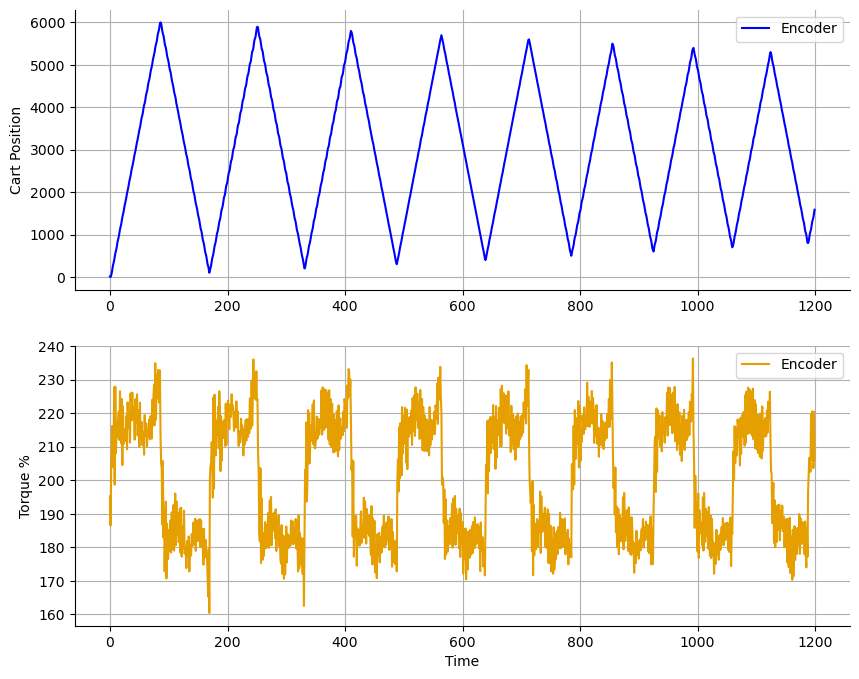

In [206]:
plt.figure(figsize=(10,8))
n=np.arange(0,len(df),1)
plt.subplot(211)
plt.plot(n,df['x3'], color='b', label='Encoder')
plt.ylabel("Cart Position")
plt.grid(True)
plt.legend()
sns.despine()
plt.subplot(212)
plt.plot(n,df['u'], color='#E69F00', label='Encoder')
plt.ylabel("Torque %")
plt.xlabel("Time")
plt.grid(True)
plt.legend()
sns.despine()
plt.show()

       n      x1      x3      u     Error  RealTime  simulateTime
86  86.0  3908.0  6000.0  213.0 -0.012036  4.337964          4.35
Max:  86


     n      x1   x3      u     Error  RealTime  simulateTime
1  1.0  3908.0  0.0  186.5 -0.001211  0.098789           0.1
Min:  1


       n      x1      x3      u     Error  RealTime  simulateTime
0    1.0  3908.0     0.0  186.5 -0.001211  0.098789          0.10
1    2.0  3908.0    42.0  203.8 -0.009694  0.140306          0.15
2    3.0  3908.0    99.0  210.2  0.001123  0.201123          0.20
3    4.0  3908.0   187.0  216.2  0.010198  0.260198          0.25
4    5.0  3908.0   269.0  206.8 -0.003293  0.296707          0.30
..   ...     ...     ...    ...       ...       ...           ...
81  82.0  3908.0  5759.0  232.9 -0.011588  4.138412          4.15
82  83.0  3908.0  5804.0  232.3 -0.008314  4.191686          4.20
83  84.0  3908.0  5881.0  223.1  0.011681  4.261681          4.25
84  85.0  3908.0  5980.0  232.7  0.007147  4.307147          4.30

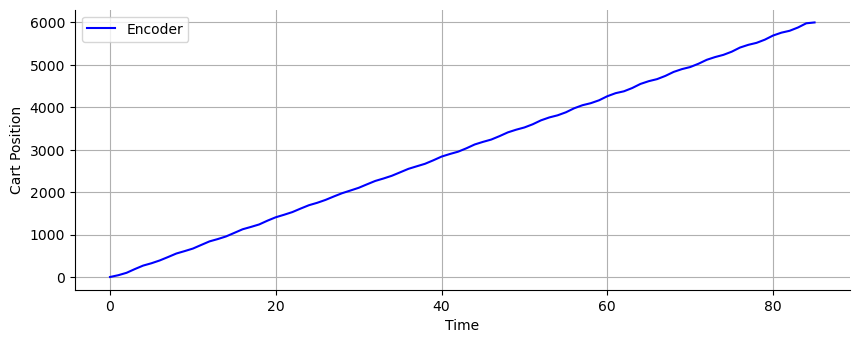

In [207]:
print(df[(df["x3"] >= max(df['x3']))])
indices_max = df[df['x3'] == df['x3'].max()].index.tolist()
print("Max: ",indices_max[0])
print("\n")
print(df[(df["x3"] <= min(df['x3']))])
indices_min = df[df['x3'] == df['x3'].min()].index.tolist()
print("Min: ",indices_min[0])
print("\n")
df.index = df.index.astype(int)  # Converte o índice para inteiro
df = df[(df.index >= int(indices_min[0])) & (df.index <= int(indices_max[0]))]
df = df.reset_index(drop=True)
print(df)
print("\n \n \n \n")
plt.figure(figsize=(10,8))
n=np.arange(0,len(df),1)
plt.subplot(211)
plt.plot(n,df['x3'], color='b', label='Encoder')
plt.ylabel("Cart Position")
plt.xlabel("Time")
plt.grid(True)
plt.legend()
sns.despine()

Se tivermos um dataset com tempo e velocidade, podemos calcular a aceleração como:

$$ a =\frac{\Delta v}{\Delta t}$$
  
Ou seja:

$$ a =\frac{v_f - v_i}{t_f - t_i}$$

Então podemos calcular $b$ para cada ponto e obter uma média.
$$ b = \frac{m_c a}{v} $$

In [208]:
exp1 = df['x3']
v_i = ((df["x3"][19]-3000)/10000)-((df["x3"][0]-3000)/10000)
v_f = ((df["x3"][len(df)-1]-3000)/10000)-((df["x3"][len(df)-21]-3000)/10000)
t_i = 0
t_f = len(df)*.05
v = (((df["x3"][2]-3000)/10000)-((df["x3"][0]-3000)/10000))/.1


a = (v_f-v_i)/(t_f-t_i)

print(f'a = ',a)
print(f'v = ',v)

m_c = .330

b1 = (a*m_c)/v_i
print("\n Valor tabela:",round(b1,3),"\n")
print("\n Valor real:",b1,"\n")

a =  0.0013023255813953475
v =  0.09899999999999964

 Valor tabela: 0.003 


 Valor real: 0.0032362006164191616 



## 15/Feb/25
### 16:04

In [209]:
df = pd.read_csv('CSV/Data_15_Feb_25_16-04.csv',header=None)
df = df.T
df.columns = ["n","x1","x3","u","Error","RealTime","simulateTime"]
df

,n,x1,x3,u,Error,RealTime,simulateTime
0,0.0,3908.0,2000.0,198.3,0.011597,0.061597,0.05
1,1.0,3908.0,1895.0,171.5,-0.003165,0.096835,0.10
2,2.0,3908.0,1810.0,190.5,-0.013467,0.136533,0.15
3,3.0,3908.0,1715.0,177.7,0.004383,0.204383,0.20
4,4.0,3908.0,1552.0,190.0,0.013152,0.263152,0.25
...,...,...,...,...,...,...,...
1196,1196.0,3908.0,4455.0,194.2,-0.000473,59.849527,59.85
1197,1197.0,3908.0,4256.0,201.6,0.031687,59.931687,59.90
1198,1198.0,3908.0,4054.0,191.1,0.002092,59.952092,59.95
1199,1199.0,3908.0,4005.0,198.7,-0.032224,59.967776,60.00


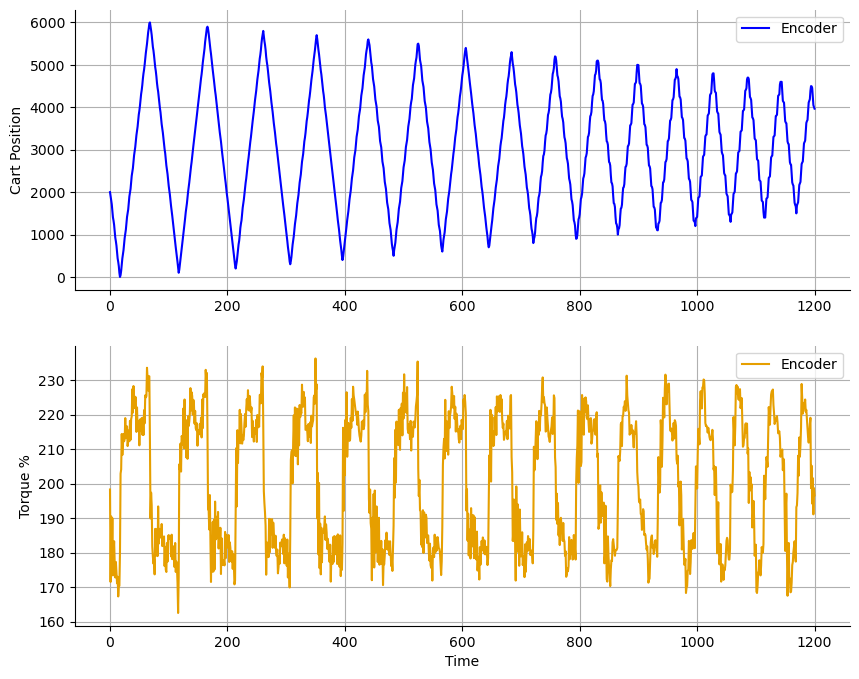

In [210]:
plt.figure(figsize=(10,8))
n=np.arange(0,len(df),1)
plt.subplot(211)
plt.plot(n,df['x3'], color='b', label='Encoder')
plt.ylabel("Cart Position")
plt.grid(True)
plt.legend()
sns.despine()
plt.subplot(212)
plt.plot(n,df['u'], color='#E69F00', label='Encoder')
plt.ylabel("Torque %")
plt.xlabel("Time")
plt.grid(True)
plt.legend()
sns.despine()
plt.show()

       n      x1      x3      u     Error  RealTime  simulateTime
68  68.0  3908.0  6000.0  212.7  0.006433  3.456433          3.45
Max:  68


       n      x1   x3      u     Error  RealTime  simulateTime
17  17.0  3908.0  0.0  180.2 -0.001328  0.898672           0.9
Min:  17


       n      x1      x3      u     Error  RealTime  simulateTime
0   17.0  3908.0     0.0  180.2 -0.001328  0.898672          0.90
1   18.0  3908.0    45.0  202.9 -0.009690  0.940310          0.95
2   19.0  3908.0   146.0  204.1  0.002282  1.002282          1.00
3   20.0  3908.0   294.0  214.4  0.008146  1.058146          1.05
4   21.0  3908.0   436.0  208.3 -0.000649  1.099351          1.10
5   22.0  3908.0   531.0  211.3 -0.009216  1.140784          1.15
6   23.0  3908.0   632.0  214.4  0.000250  1.200250          1.20
7   24.0  3908.0   777.0  212.3  0.010296  1.260296          1.25
8   25.0  3908.0   923.0  213.0 -0.001242  1.298758          1.30
9   26.0  3908.0  1016.0  219.0 -0.011687  1.338313         

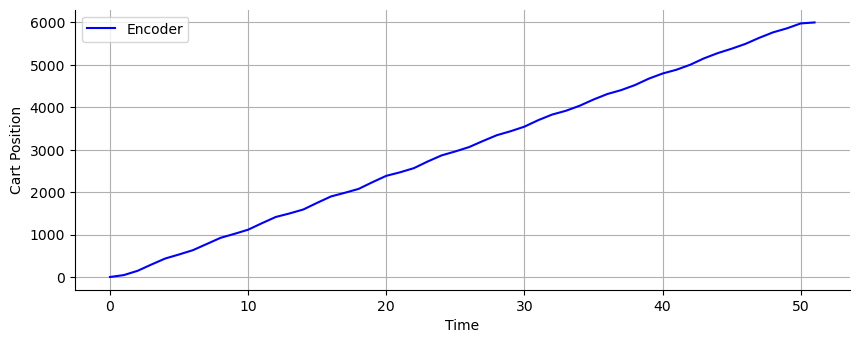

In [211]:
print(df[(df["x3"] >= max(df['x3']))])
indices_max = df[df['x3'] == df['x3'].max()].index.tolist()
print("Max: ",indices_max[0])
print("\n")
print(df[(df["x3"] <= min(df['x3']))])
indices_min = df[df['x3'] == df['x3'].min()].index.tolist()
print("Min: ",indices_min[0])
print("\n")
df.index = df.index.astype(int)  # Converte o índice para inteiro
df = df[(df.index >= int(indices_min[0])) & (df.index <= int(indices_max[0]))]
df = df.reset_index(drop=True)
print(df)
print("\n \n \n \n")
plt.figure(figsize=(10,8))
n=np.arange(0,len(df),1)
plt.subplot(211)
plt.plot(n,df['x3'], color='b', label='Encoder')
plt.ylabel("Cart Position")
plt.xlabel("Time")
plt.grid(True)
plt.legend()
sns.despine()

Se tivermos um dataset com tempo e velocidade, podemos calcular a aceleração como:

$$ a =\frac{\Delta v}{\Delta t}$$
  
Ou seja:

$$ a =\frac{v_f - v_i}{t_f - t_i}$$

Então podemos calcular $b$ para cada ponto e obter uma média.
$$ b = \frac{m_c a}{v} $$

In [212]:
exp2 = df['x3']
v_i = ((df["x3"][19]-3000)/10000)-((df["x3"][0]-3000)/10000)
v_f = ((df["x3"][len(df)-1]-3000)/10000)-((df["x3"][len(df)-21]-3000)/10000)
t_i = 0
t_f = len(df)*.05
v = (((df["x3"][2]-3000)/10000)-((df["x3"][0]-3000)/10000))/.1


a = (v_f-v_i)/(t_f-t_i)

print(f'a = ',a)
print(f'v = ',v)

m_c = .330

b1 = (a*m_c)/v_i
print("\n Valor tabela:",round(b1,3),"\n")
print("\n Valor real:",b1,"\n")

a =  0.002615384615384626
v =  0.14600000000000002

 Valor tabela: 0.004 


 Valor real: 0.003861641713990724 



## 15/Feb/25
### 16:12

In [213]:
df = pd.read_csv('CSV/Data_15_Feb_25_16-12.csv',header=None)
df = df.T
df.columns = ["n","x1","x3","u","Error","RealTime","simulateTime"]
df

,n,x1,x3,u,Error,RealTime,simulateTime
0,0.0,3895.0,2000.0,205.1,0.012434,0.062434,0.05
1,1.0,3895.0,1822.0,166.5,-0.004912,0.095088,0.10
2,2.0,3895.0,1694.0,199.9,-0.011797,0.138203,0.15
3,3.0,3895.0,1522.0,174.5,0.003722,0.203722,0.20
4,4.0,3896.0,1258.0,194.8,0.011683,0.261683,0.25
...,...,...,...,...,...,...,...
1196,1196.0,3896.0,3000.0,201.3,-0.004612,59.845388,59.85
1197,1197.0,3896.0,3000.0,201.3,0.031466,59.931466,59.90
1198,1198.0,3896.0,3000.0,201.4,0.004302,59.954302,59.95
1199,1199.0,3896.0,3000.0,201.3,-0.029962,59.970038,60.00


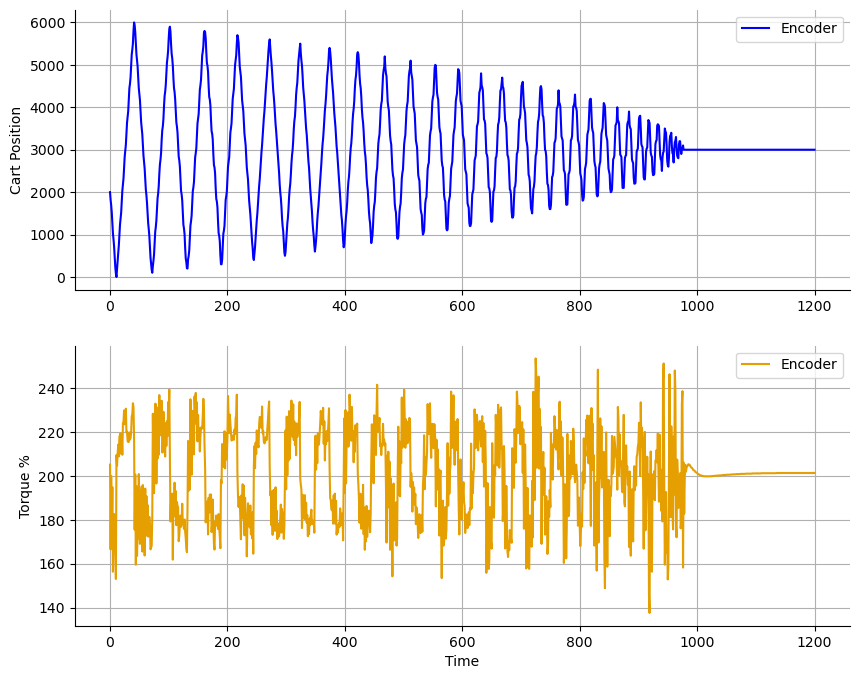

In [214]:
plt.figure(figsize=(10,8))
n=np.arange(0,len(df),1)
plt.subplot(211)
plt.plot(n,df['x3'], color='b', label='Encoder')
plt.ylabel("Cart Position")
plt.grid(True)
plt.legend()
sns.despine()
plt.subplot(212)
plt.plot(n,df['u'], color='#E69F00', label='Encoder')
plt.ylabel("Torque %")
plt.xlabel("Time")
plt.grid(True)
plt.legend()
sns.despine()
plt.show()

       n      x1      x3      u     Error  RealTime  simulateTime
41  41.0  3896.0  6000.0  217.1 -0.005437  2.094563           2.1
Max:  41


       n      x1   x3      u     Error  RealTime  simulateTime
11  11.0  3896.0  0.0  209.5  0.003956  0.603956           0.6
Min:  11


       n      x1      x3      u     Error  RealTime  simulateTime
0   11.0  3896.0     0.0  209.5  0.003956  0.603956          0.60
1   12.0  3896.0   194.0  204.7  0.007604  0.657604          0.65
2   13.0  3896.0   406.0  210.1 -0.002893  0.697107          0.70
3   14.0  3896.0   562.0  214.2 -0.009711  0.740289          0.75
4   15.0  3896.0   738.0  208.9  0.001726  0.801726          0.80
5   16.0  3896.0   986.0  217.8  0.013651  0.863651          0.85
6   17.0  3896.0  1230.0  218.7 -0.002429  0.897571          0.90
7   18.0  3896.0  1370.0  219.4 -0.014521  0.935479          0.95
8   19.0  3896.0  1518.0  210.0  0.002825  1.002825          1.00
9   20.0  3896.0  1786.0  217.3  0.014525  1.064525         

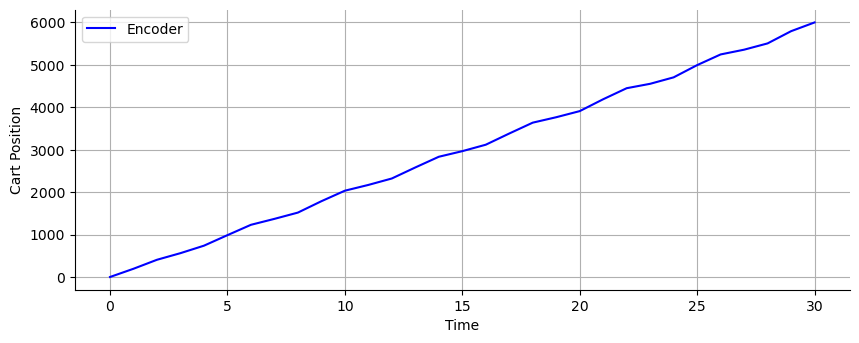

In [215]:
print(df[(df["x3"] >= max(df['x3']))])
indices_max = df[df['x3'] == df['x3'].max()].index.tolist()
print("Max: ",indices_max[0])
print("\n")
print(df[(df["x3"] <= min(df['x3']))])
indices_min = df[df['x3'] == df['x3'].min()].index.tolist()
print("Min: ",indices_min[0])
print("\n")
df.index = df.index.astype(int)  # Converte o índice para inteiro
df = df[(df.index >= int(indices_min[0])) & (df.index <= int(indices_max[0]))]
df = df.reset_index(drop=True)
print(df)
print("\n \n \n \n")
plt.figure(figsize=(10,8))
n=np.arange(0,len(df),1)
plt.subplot(211)
plt.plot(n,df['x3'], color='b', label='Encoder')
plt.ylabel("Cart Position")
plt.xlabel("Time")
plt.grid(True)
plt.legend()
sns.despine()

Se tivermos um dataset com tempo e velocidade, podemos calcular a aceleração como:

$$ a =\frac{\Delta v}{\Delta t}$$
  
Ou seja:

$$ a =\frac{v_f - v_i}{t_f - t_i}$$

Então podemos calcular $b$ para cada ponto e obter uma média.
$$ b = \frac{m_c a}{v} $$

In [216]:
exp3 = df['x3']
v_i = ((df["x3"][19]-3000)/10000)-((df["x3"][0]-3000)/10000)
v_f = ((df["x3"][len(df)-1]-3000)/10000)-((df["x3"][len(df)-21]-3000)/10000)
t_i = 0
t_f = len(df)*.05
v = (((df["x3"][2]-3000)/10000)-((df["x3"][0]-3000)/10000))/.1


a = (v_f-v_i)/(t_f-t_i)

print(f'a = ',a)
print(f'v = ',v)

m_c = .330

b1 = (a*m_c)/v_i
print("\n Valor tabela:",round(b1,3),"\n")
print("\n Valor real:",b1,"\n")

a =  0.012903225806451623
v =  0.4059999999999997

 Valor tabela: 0.011 


 Valor real: 0.011306597228170569 



## 15/Feb/25
### 16:18

In [217]:
df = pd.read_csv('CSV/Data_15_Feb_25_16-18.csv',header=None)
df = df.T
df.columns = ["n","x1","x3","u","Error","RealTime","simulateTime"]
df

,n,x1,x3,u,Error,RealTime,simulateTime
0,0.0,3896.0,3000.0,201.6,0.011798,0.061798,0.05
1,1.0,3896.0,2814.0,163.7,-0.002831,0.097169,0.10
2,2.0,3896.0,2678.0,189.4,-0.012245,0.137755,0.15
3,3.0,3896.0,2514.0,165.4,0.003167,0.203167,0.20
4,4.0,3896.0,2258.0,187.5,0.011224,0.261224,0.25
...,...,...,...,...,...,...,...
1196,1196.0,3896.0,3000.0,201.4,0.006774,59.856774,59.85
1197,1197.0,3896.0,3000.0,201.4,0.037891,59.937891,59.90
1198,1198.0,3896.0,3000.0,201.4,-0.004114,59.945886,59.95
1199,1199.0,3896.0,3000.0,201.4,-0.038505,59.961495,60.00


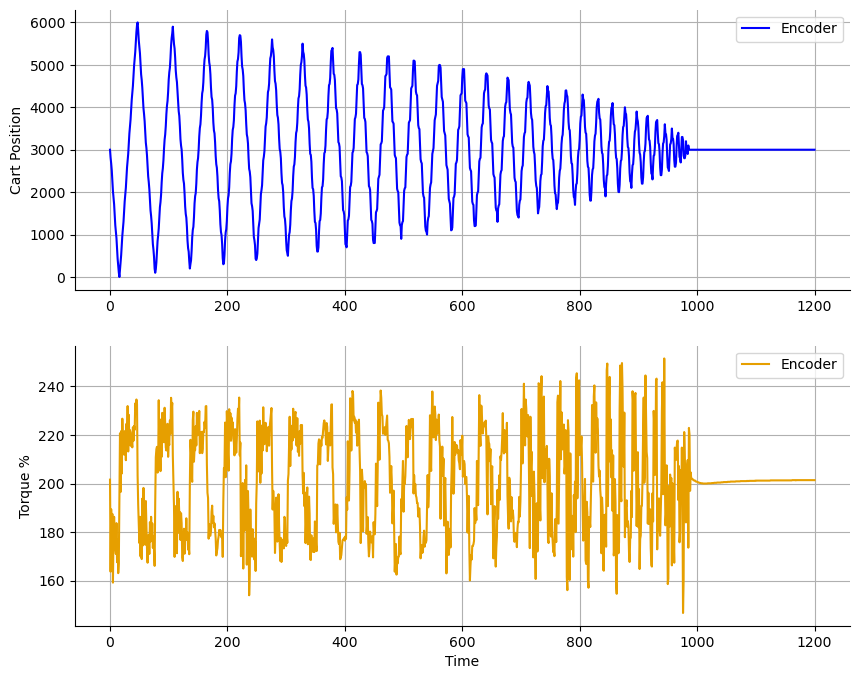

In [218]:
plt.figure(figsize=(10,8))
n=np.arange(0,len(df),1)
plt.subplot(211)
plt.plot(n,df['x3'], color='b', label='Encoder')
plt.ylabel("Cart Position")
plt.grid(True)
plt.legend()
sns.despine()
plt.subplot(212)
plt.plot(n,df['u'], color='#E69F00', label='Encoder')
plt.ylabel("Torque %")
plt.xlabel("Time")
plt.grid(True)
plt.legend()
sns.despine()
plt.show()

       n      x1      x3      u     Error  RealTime  simulateTime
47  47.0  3896.0  6000.0  203.4  0.000984  2.400984           2.4
Max:  47


       n      x1   x3      u     Error  RealTime  simulateTime
16  16.0  3896.0  0.0  194.6  0.009265  0.859265          0.85
Min:  16


       n      x1      x3      u     Error  RealTime  simulateTime
0   16.0  3896.0     0.0  194.6  0.009265  0.859265          0.85
1   17.0  3896.0   174.0  220.7 -0.002104  0.897896          0.90
2   18.0  3896.0   334.0  196.5 -0.006285  0.943715          0.95
3   19.0  3896.0   514.0  221.6  0.000388  1.000388          1.00
4   20.0  3896.0   746.0  204.1  0.008425  1.058425          1.05
5   21.0  3896.0   978.0  226.7 -0.001475  1.098525          1.10
6   22.0  3896.0  1134.0  216.0 -0.009212  1.140788          1.15
7   23.0  3896.0  1302.0  214.4  0.002407  1.202407          1.20
8   24.0  3896.0  1554.0  211.9  0.009319  1.259319          1.25
9   25.0  3896.0  1782.0  221.4 -0.002240  1.297760         

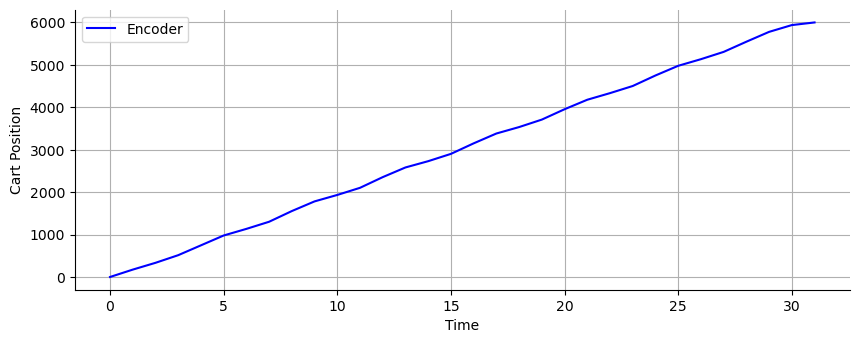

In [219]:
print(df[(df["x3"] >= max(df['x3']))])
indices_max = df[df['x3'] == df['x3'].max()].index.tolist()
print("Max: ",indices_max[0])
print("\n")
print(df[(df["x3"] <= min(df['x3']))])
indices_min = df[df['x3'] == df['x3'].min()].index.tolist()
print("Min: ",indices_min[0])
print("\n")
df.index = df.index.astype(int)  # Converte o índice para inteiro
df = df[(df.index >= int(indices_min[0])) & (df.index <= int(indices_max[0]))]
df = df.reset_index(drop=True)
print(df)
print("\n \n \n \n")
plt.figure(figsize=(10,8))
n=np.arange(0,len(df),1)
plt.subplot(211)
plt.plot(n,df['x3'], color='b', label='Encoder')
plt.ylabel("Cart Position")
plt.xlabel("Time")
plt.grid(True)
plt.legend()
sns.despine()

Se tivermos um dataset com tempo e velocidade, podemos calcular a aceleração como:

$$ a =\frac{\Delta v}{\Delta t}$$
  
Ou seja:

$$ a =\frac{v_f - v_i}{t_f - t_i}$$

Então podemos calcular $b$ para cada ponto e obter uma média.
$$ b = \frac{m_c a}{v} $$

In [220]:
exp4 = df['x3']
v_i = ((df["x3"][19]-3000)/10000)-((df["x3"][0]-3000)/10000)
v_f = ((df["x3"][len(df)-1]-3000)/10000)-((df["x3"][len(df)-21]-3000)/10000)
t_i = 0
t_f = len(df)*.05
v = (((df["x3"][2]-3000)/10000)-((df["x3"][0]-3000)/10000))/.1


a = (v_f-v_i)/(t_f-t_i)

print(f'a = ',a)
print(f'v = ',v)

m_c = .330

b1 = (a*m_c)/v_i
print("\n Valor tabela:",round(b1,3),"\n")
print("\n Valor real:",b1,"\n")

a =  0.01174999999999999
v =  0.33399999999999985

 Valor tabela: 0.01 


 Valor real: 0.010451482479784358 



## 15/Feb/25
### 16:20

In [221]:
df = pd.read_csv('CSV/Data_15_Feb_25_16-20.csv',header=None)
df = df.T
df.columns = ["n","x1","x3","u","Error","RealTime","simulateTime"]
df

,n,x1,x3,u,Error,RealTime,simulateTime
0,0.0,3896.0,3000.0,201.7,0.008421,0.058421,0.05
1,1.0,3896.0,2778.0,155.8,0.000113,0.100113,0.10
2,2.0,3896.0,2578.0,193.1,-0.008713,0.141287,0.15
3,3.0,3896.0,2373.0,153.0,-0.000285,0.199715,0.20
4,4.0,3896.0,2073.0,194.7,0.010163,0.260163,0.25
...,...,...,...,...,...,...,...
1196,1196.0,3896.0,3000.0,201.3,0.000390,59.850390,59.85
1197,1197.0,3896.0,3000.0,201.3,0.042779,59.942779,59.90
1198,1198.0,3896.0,3000.0,201.3,0.000988,59.950988,59.95
1199,1199.0,3896.0,3000.0,201.3,-0.041496,59.958504,60.00


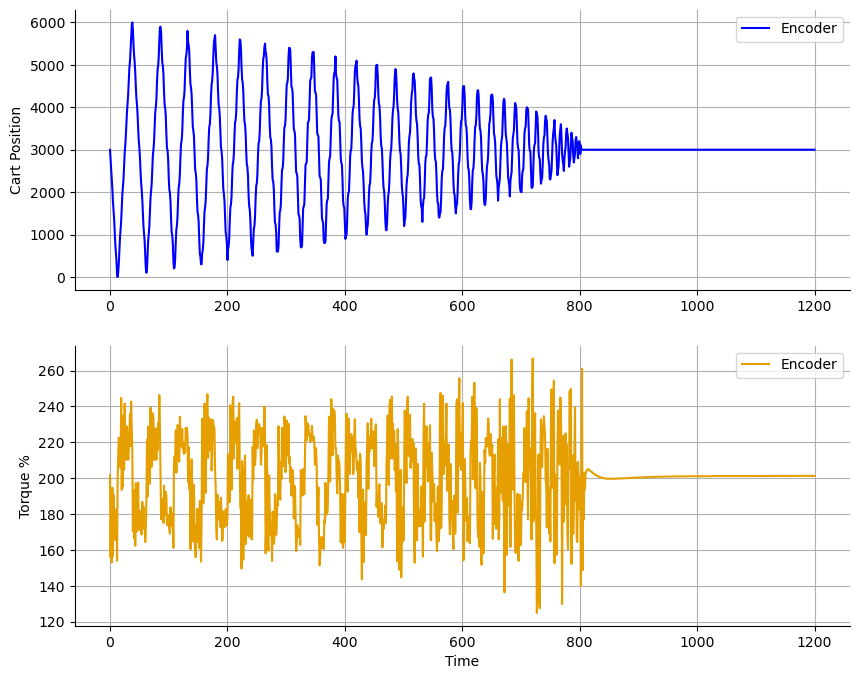

In [222]:
plt.figure(figsize=(10,8))
n=np.arange(0,len(df),1)
plt.subplot(211)
plt.plot(n,df['x3'], color='b', label='Encoder')
plt.ylabel("Cart Position")
plt.grid(True)
plt.legend()
sns.despine()
plt.subplot(212)
plt.plot(n,df['u'], color='#E69F00', label='Encoder')
plt.ylabel("Torque %")
plt.xlabel("Time")
plt.grid(True)
plt.legend()
sns.despine()
plt.show()

       n      x1      x3      u     Error  RealTime  simulateTime
38  38.0  3896.0  6000.0  214.5 -0.010014  1.939986          1.95
Max:  38


       n      x1   x3      u    Error  RealTime  simulateTime
13  13.0  3896.0  0.0  199.2 -0.00193   0.69807           0.7
Min:  13


       n      x1      x3      u     Error  RealTime  simulateTime
0   13.0  3896.0     0.0  199.2 -0.001930  0.698070          0.70
1   14.0  3896.0   112.0  213.3 -0.010555  0.739445          0.75
2   15.0  3896.0   322.0  222.6  0.001683  0.801683          0.80
3   16.0  3896.0   632.0  214.3  0.010551  0.860551          0.85
4   17.0  3896.0   927.0  208.1 -0.001397  0.898603          0.90
5   18.0  3896.0  1117.0  205.9 -0.011699  0.938301          0.95
6   19.0  3896.0  1317.0  244.8  0.001773  1.001773          1.00
7   20.0  3896.0  1632.0  193.5  0.012695  1.062695          1.05
8   21.0  3896.0  1942.0  229.0 -0.002374  1.097626          1.10
9   22.0  3896.0  2112.0  195.3 -0.012874  1.137126          1

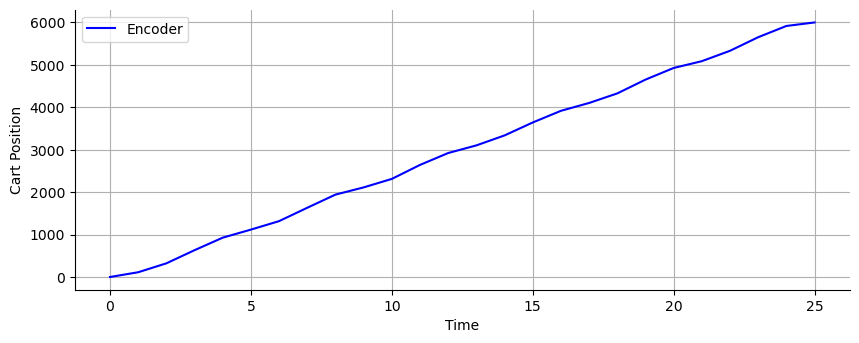

In [223]:
print(df[(df["x3"] >= max(df['x3']))])
indices_max = df[df['x3'] == df['x3'].max()].index.tolist()
print("Max: ",indices_max[0])
print("\n")
print(df[(df["x3"] <= min(df['x3']))])
indices_min = df[df['x3'] == df['x3'].min()].index.tolist()
print("Min: ",indices_min[0])
print("\n")
df.index = df.index.astype(int)  # Converte o índice para inteiro
df = df[(df.index >= int(indices_min[0])) & (df.index <= int(indices_max[0]))]
df = df.reset_index(drop=True)
print(df)
print("\n \n \n \n")
plt.figure(figsize=(10,8))
n=np.arange(0,len(df),1)
plt.subplot(211)
plt.plot(n,df['x3'], color='b', label='Encoder')
plt.ylabel("Cart Position")
plt.xlabel("Time")
plt.grid(True)
plt.legend()
sns.despine()

Se tivermos um dataset com tempo e velocidade, podemos calcular a aceleração como:

$$ a =\frac{\Delta v}{\Delta t}$$
  
Ou seja:

$$ a =\frac{v_f - v_i}{t_f - t_i}$$

Então podemos calcular $b$ para cada ponto e obter uma média.
$$ b = \frac{m_c a}{v} $$

In [224]:
exp5 = df['x3']
v_i = ((df["x3"][19]-3000)/10000)-((df["x3"][0]-3000)/10000)
v_f = ((df["x3"][len(df)-1]-3000)/10000)-((df["x3"][len(df)-21]-3000)/10000)
t_i = 0
t_f = len(df)*.05
v = (((df["x3"][2]-3000)/10000)-((df["x3"][0]-3000)/10000))/.1


a = (v_f-v_i)/(t_f-t_i)

print(f'a = ',a)
print(f'v = ',v)

m_c = .330

b1 = (a*m_c)/v_i
print("\n Valor tabela:",round(b1,3),"\n")
print("\n Valor real:",b1,"\n")

a =  0.01776923076923073
v =  0.32200000000000006

 Valor tabela: 0.013 


 Valor real: 0.012605000330709677 



In [166]:
exp = [np.array(exp1),
 np.array(exp2),
 np.array(exp3),
 np.array(exp4),
 np.array(exp5)]
exp

[array([   0.,   42.,   99.,  187.,  269.,  324.,  390.,  470.,  553.,
         610.,  670.,  755.,  839.,  894.,  956., 1040., 1125., 1180.,
        1239., 1328., 1408., 1467., 1530., 1613., 1692., 1749., 1817.,
        1898., 1975., 2038., 2102., 2184., 2264., 2322., 2386., 2467.,
        2549., 2609., 2668., 2750., 2838., 2899., 2954., 3034., 3124.,
        3185., 3240., 3321., 3409., 3472., 3525., 3600., 3693., 3761.,
        3811., 3882., 3977., 4049., 4097., 4165., 4261., 4333., 4377.,
        4454., 4551., 4616., 4664., 4740., 4834., 4900., 4949., 5027.,
        5120., 5184., 5236., 5310., 5408., 5472., 5519., 5594., 5692.,
        5759., 5804., 5881., 5980., 6000.]),
 array([   0.,   45.,  146.,  294.,  436.,  531.,  632.,  777.,  923.,
        1016., 1115., 1268., 1415., 1498., 1592., 1749., 1899., 1985.,
        2077., 2235., 2385., 2468., 2566., 2723., 2866., 2960., 3063.,
        3206., 3342., 3436., 3544., 3697., 3828., 3918., 4037., 4183.,
        4313., 4405., 4524., 467

In [119]:
exp = [(np.array(exp1)-3000)/10000,
 (np.array(exp2)-3000)/10000,
 (np.array(exp3)-3000)/10000,
# (np.array(exp4)-3000)/10000,
 (np.array(exp5)-3000)/10000]
exp

[array([-0.3   , -0.2958, -0.2901, -0.2813, -0.2731, -0.2676, -0.261 ,
        -0.253 , -0.2447, -0.239 , -0.233 , -0.2245, -0.2161, -0.2106,
        -0.2044, -0.196 , -0.1875, -0.182 , -0.1761, -0.1672, -0.1592,
        -0.1533, -0.147 , -0.1387, -0.1308, -0.1251, -0.1183, -0.1102,
        -0.1025, -0.0962, -0.0898, -0.0816, -0.0736, -0.0678, -0.0614,
        -0.0533, -0.0451, -0.0391, -0.0332, -0.025 , -0.0162, -0.0101,
        -0.0046,  0.0034,  0.0124,  0.0185,  0.024 ,  0.0321,  0.0409,
         0.0472,  0.0525,  0.06  ,  0.0693,  0.0761,  0.0811,  0.0882,
         0.0977,  0.1049,  0.1097,  0.1165,  0.1261,  0.1333,  0.1377,
         0.1454,  0.1551,  0.1616,  0.1664,  0.174 ,  0.1834,  0.19  ,
         0.1949,  0.2027,  0.212 ,  0.2184,  0.2236,  0.231 ,  0.2408,
         0.2472,  0.2519,  0.2594,  0.2692,  0.2759,  0.2804,  0.2881,
         0.298 ,  0.3   ]),
 array([-0.3   , -0.2955, -0.2854, -0.2706, -0.2564, -0.2469, -0.2368,
        -0.2223, -0.2077, -0.1984, -0.1885, -0.17

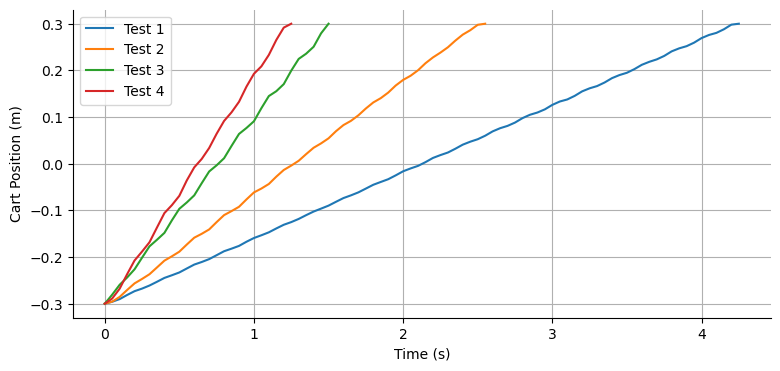

In [124]:
plt.show()
plt.figure(figsize=(9, 4))
time_step = 0.05
for i, curva in enumerate(exp):
    x = [j * time_step for j in range(len(curva))]
    plt.plot(x, curva, label=f'Test {i+1}')

plt.ylabel("Cart Position (m)")
plt.xlabel("Time (s)")
plt.grid(True)
plt.legend()
sns.despine()
plt.savefig('figure_sipe_2.pdf', format="pdf",bbox_inches='tight')
plt.show()

In [225]:
a =  (0.0013023255813953475 + 0.002615384615384626 + 0.01174999999999999 + 0.012903225806451623 + 0.01776923076923073) / 5
v =  (0.09899999999999964 + 0.14600000000000002 + 0.4059999999999997 + 0.33399999999999985 + 0.32200000000000006) / 5
print(f"a = ",a)
print(f"v = ",v)

a =  0.009268033354492463
v =  0.26139999999999985


In [226]:
m_c = .330
print((a*m_c)/v)

0.011700271641096077


In [229]:
print((0.009*.330)/0.262)

0.01133587786259542


Se você obteve valores diferentes para o coeficiente de atrito viscoso ($b$) em diferentes simulações:
$$ b=0.003,0.004,0.011,0.011,0.013$$

significa que o sistema pode estar sofrendo variações devido a diferentes fatores, como erros experimentais, variações de atrito no trilho ou comportamento não puramente linear.

Como Analisar os Resultados?

1️⃣ Cálculo da Média e Desvio Padrão
Para entender a variabilidade dos valores, podemos calcular a média e o desvio padrão:

$$b_{medio} = \frac{0.003+0.004+0.011+0.011+0.013}{5} = 0.008$$

$$ \sigma = \sqrt{}$$
Isso ajudará a entender se há um padrão ou se os valores estão muito dispersos.

In [176]:
b_med = (b1+b2+b3+b4+b5)/5
b_med
mu_c = (((b1-b_med)**2+(b2-b_med)**2+(b3-b_med)**2+(b4-b_med)**2+(b5-b_med)**2)/5)**(1/2)
print("\n mu_c Valor Tabela:",round(mu_c ,3),"\n")
print("\n mu_c Valor Real:",mu_c ,"\n")


 mu_c Valor Tabela: 0.004 


 mu_c Valor Real: 0.003938078583790972 



Valor chat mu_c = 0.005

| Variable   | Parameter                                 | Value  | Unit         |
|------------|------------------------------------------|--------|--------------|
| $\mu_{c}$  | The friction coefficient between the cart and the guiderail | 0.004  | $N/m/s$      |
| $\mu_{p}$  | Pendulum damping coefficient             | 0.001  | $N/m/s$      |
| $I_{m}$   | The rotary inertia of the pendulum rod   | 0.013  | $kg \, m^2$  |